In [4]:
import matplotlib.pyplot as plt
import sys
from matplotlib import gridspec
sys.path.append('../../Codes/library/')

from funcs import*

plt.rcParams['text.usetex'] = True
Text_files_path = '/Users/robertomorantovar/Dropbox/Research/Immune_system/'
output_plot = '/Users/robertomorantovar/Dropbox/My_Documents/Science/Projects/Immune_System/_Repository/Figures/exponential_proofreading/poisson_mechanism/'
os.makedirs(output_plot, exist_ok=True)

%autosave 60

Autosaving every 60 seconds


In [2]:
def simulate_exact(alpha, k_on, sigma, lam, lam_B, delta, x0, T=None, T_peak=None, Theta=None, rng=np.random):
    t = 0.0
    n = x0
    traj = [(t, n)]
    div = []
    while True:
        if T is not None and t >= T: break
        if Theta is not None and n >= Theta: break #comment to create complete trajectories even after division threshold reached

         # --- event 1: birth clock (NHPP) ---
        if t < T_peak:
            r = rng.exponential(1.0)
            tau_b = (1.0/lam) * np.log(1.0 + (lam/(k_on*alpha**sigma))*r*np.exp(-lam*t))
        else:
            tau_b = np.inf

        # --- event 2: death clock ---
        if n > 0:
            tau_d = rng.exponential(1.0/(delta*n)) # mean = 1/(delta*n)
        else:
            tau_d = np.inf

        # --- event 3: "B" event (halving) ---
        if (Theta is not None) and (n > Theta) and (lam_B > 0.0):
            tau_B = rng.exponential(1.0 / (lam_B))  # mean = 1/lam_B
        else:
            tau_B = np.inf

        # choose which event happens next
        if tau_b <= tau_d and tau_b <= tau_B:
            t += tau_b
            n += 1
        elif tau_d <= tau_b and tau_d <= tau_B:
            t += tau_d
            n -= 1
        else:
            t += tau_B
            n //= 2   # integer halving; use n = n / 2 for float halving
            div.append(t/6)  # record division time if Theta used

        # if tau_b < tau_d:
        #     t += tau_b
        #     n += 1
        # else:
        #     t += tau_d
        #     n -= 1

        traj.append((t/6, n))

    return traj, div  # also return division time if Theta used

In [33]:
beta = 2.2
lam_B = 0.25
sigmas = [1.0]
Thetas = [10.]
T = 12
T_peak = 18
k_on = 1e-3
times = np.linspace(0, T, 100)
Ks = np.logspace(0.01, 1.5, 3)
print(Ks)
Ks = np.array([1.1])
data_simulation = defaultdict(list)
trajectories = []
statistics = defaultdict(list)
for Theta in Thetas:
    for sigma in sigmas:
        for i_ens in range(100):
            for K, omega in zip(Ks, Ks**beta):
                ts_act = []
                for n in range(int(omega)):
                    traj1, div = simulate_exact(alpha=1/K, k_on = k_on, sigma = sigma, lam=1, lam_B = lam_B, delta=0.01, x0=0, T=T, T_peak = T_peak, Theta=Theta)
                    trajectories.append((traj1, div, K))
                


[ 1.02329299  5.68852931 31.6227766 ]


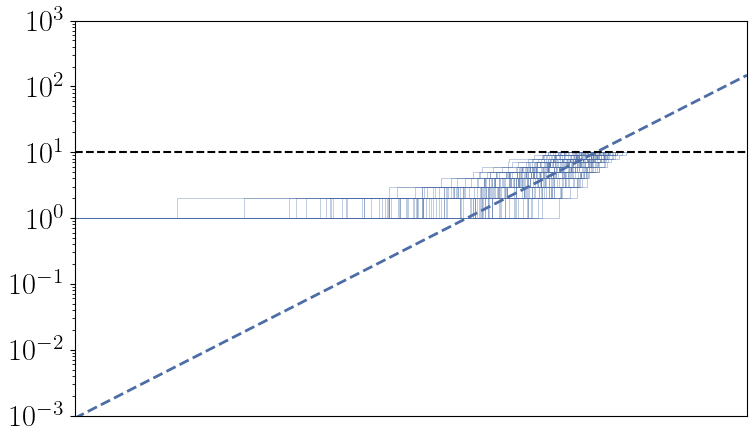

In [34]:
plt.style.use("seaborn-v0_8-colorblind")
fig_pi, ax_pi = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})

for i in range(len(trajectories)):
    traj1, div, K = trajectories[i]
    line, = ax_pi.step(*zip(*traj1), lw = .5, label = r'$%.1f \times 10^{%.1e}$'%(K/10, np.log10(K)), color = my_blue, alpha = .5)

ax_pi.plot(times/6, k_on*(K)**(-1)*np.exp(times), color=line.get_color(), ls = 'dashed', lw = 2)
ax_pi.hlines(Thetas[0], 0, T, colors='k', linestyles='dashed')

# my_plot_layout(ax=ax_pi, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
# ax.set_yscale('log')
ax_pi.set_ylim(bottom=0.001, top = 100.2*Thetas[0])
ax_pi.set_xlim(left=0, right=T/6)
ax_pi.tick_params(axis='both', which='major', labelsize=22)
# ax_pi.legend(loc = 2, fontsize = 14, title = r'$K$', title_fontsize = 16)
fig_pi.savefig(output_plot + 'trajectories.pdf')
ax_pi.set_yscale('log')
ax_pi.set_xticks([])
fig_pi.savefig(output_plot + 'trajectories_log.pdf')
